In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.codon import CodonDataset
from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, ESMCodonEncoder

from evo.sequence import get_mutant
from evo.dms import get_site_by_site_consensus
from evo.dataset import ComplexCherriesDataset
from evo.tokenization import CodonVocab

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/scratch/users/stephen.lu/projects/protevo/logs/train/runs/2025-10-20_02-46-17")
ckpt_path = ckpt_dir / "checkpoints/last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
vocab = CodonVocab.from_codons()
esm_encoder = ESMCodonEncoder.from_pretrained(
    codon_vocab=vocab,
    codon_embed_dim=384,
)
net = PEINT(
    enc_model=esm_encoder,
    evo_vocab=vocab,
    embed_dim=1024,
    num_heads=16,
    num_chains=2,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_len=1022,
    dropout_p=0.0,
    use_chain_embedding=True,
    use_attention_bias=True,
    causal_decoder=True,
)
module = PEINTModule.load_from_checkpoint(ckpt_path, net=net, map_location=device, strict=False)
module.net.in_embedding.codon_embedding.weight = module.net.enc_model.codon_embedding.weight
module.eval()
# module.load_state_dict(torch.load(ckpt_path, map_location=device)['state_dict'], strict=False)

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['net.enc_model.codon_to_aa_mapping', 'net.in_embedding.codon_embedding.weight']


In [ ]:
module.eval()

In [49]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = CodonDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        permute_chain_order=False,
        embed_x_per_chain=True,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())
        
        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

In [32]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module)

Inference: 100%|███████████████████████████████████████████████████████████████████████████| 1968/1968 [03:44<00:00,  8.78it/s]


In [34]:
print('test perplexity: ', np.mean(ppl))

test perplexity:  1.3904431


In [35]:
lls.shape, bls.shape, ppl.shape

((62972,), (62972, 2), (62972,))

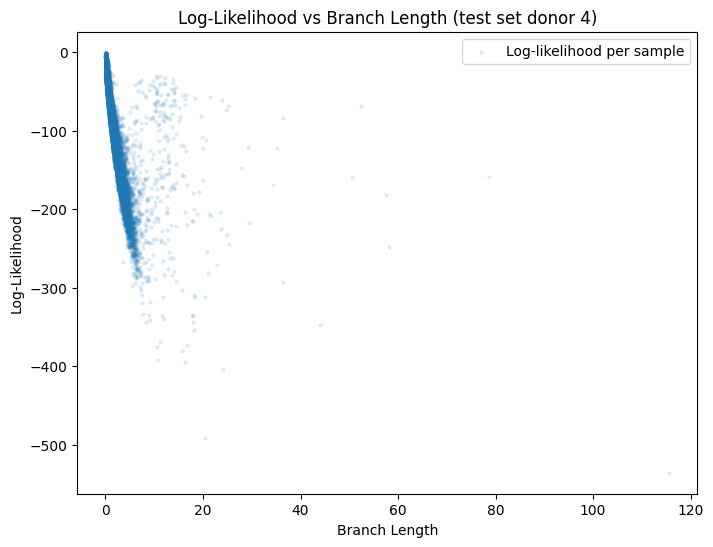

In [47]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (test set donor 4)")
ax.legend()
plt.show()

In [ ]:
# for each transition in the test set, sample a child sequence using the model and compute its hamming distance + codon usage compared to the true child sequence
real_child_nt_sequences = []
sim_child_nt_sequences = []
n_batches = 100

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # decode the true child sequence using the vocab
    true_child_seqs = [decode_sequence_from_toks(y_tgt[i].cpu().numpy()) for i in range(y_tgt.size(0))]
    assert len(true_child_seqs[0]) == y_sizes[0].sum().item() * 3

    # sample a child sequence using the model
    
    n_batches -= 1
    if n_batches == 0:
        break

Inference:   0%|                                                                                      | 0/1968 [00:00<?, ?it/s]

690
690
